In [8]:
# 📦 Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

# Load data
df = pd.read_csv("RADCURE_Clinical_v04_20241219.csv")

# 🔍 Explore the dataset
print(df.shape)
print(df.columns)
df.head()


(3346, 34)
Index(['patient_id', 'Age', 'Sex', 'ECOG PS', 'Smoking PY', 'Smoking Status',
       'Ds Site', 'Subsite', 'T', 'N', 'M ', 'Stage', 'Path', 'HPV',
       'Tx Modality', 'Chemo', 'RT Start', 'Dose', 'Fx', 'Last FU', 'Status',
       'Length FU', 'Date of Death', 'Cause of Death', 'Local', 'Date Local',
       'Regional', 'Date Regional', 'Distant', 'Date Distant', '2nd Ca',
       'Date 2nd Ca', 'RADCURE-challenge', 'ContrastEnhanced'],
      dtype='object')


,patient_id,Age,Sex,ECOG PS,Smoking PY,Smoking Status,Ds Site,Subsite,T,N,...,Local,Date Local,Regional,Date Regional,Distant,Date Distant,2nd Ca,Date 2nd Ca,RADCURE-challenge,ContrastEnhanced
0,RADCURE-0005,62.6,Female,ECOG 0,50,Ex-smoker,Oropharynx,post wall,T4b,N2c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,RADCURE-0006,87.3,Male,ECOG 2,25,Ex-smoker,Larynx,Glottis,T1b,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2,RADCURE-0007,49.9,Male,ECOG 1,15,Ex-smoker,Oropharynx,Tonsil,T3,N2b,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
3,RADCURE-0009,72.3,Male,ECOG 1,30,Ex-smoker,Unknown,NaN,T0,N2c,...,NaN,NaN,NaN,NaN,NaN,NaN,S (suspicious),2008-05-27,0,0
4,RADCURE-0010,59.7,Female,ECOG 0,0,Non-smoker,Oropharynx,Tonsillar Fossa,T4b,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [13]:
# Rename columns
df = df.rename(columns={
    'Length FU': 'time',
    'Status': 'event',
    'Tx Modality': 'Treatment'
})

# Convert event column to boolean (1 = dead, 0 = alive)
df['event'] = df['event'].map({'Dead': 1, 'Alive': 0}).astype(bool)

# Drop rows missing essential fields
df = df.dropna(subset=['time', 'event', 'Age', 'Stage', 'Treatment'])

# Convert Stage and Treatment to categorical
df['Stage'] = df['Stage'].astype('category')
df['Treatment'] = df['Treatment'].astype('category')

df.head()



,patient_id,Age,Sex,ECOG PS,Smoking PY,Smoking Status,Ds Site,Subsite,T,N,...,Local,Date Local,Regional,Date Regional,Distant,Date Distant,2nd Ca,Date 2nd Ca,RADCURE-challenge,ContrastEnhanced
0,RADCURE-0005,62.6,Female,ECOG 0,50,Ex-smoker,Oropharynx,post wall,T4b,N2c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,RADCURE-0006,87.3,Male,ECOG 2,25,Ex-smoker,Larynx,Glottis,T1b,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
2,RADCURE-0007,49.9,Male,ECOG 1,15,Ex-smoker,Oropharynx,Tonsil,T3,N2b,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1
3,RADCURE-0009,72.3,Male,ECOG 1,30,Ex-smoker,Unknown,NaN,T0,N2c,...,NaN,NaN,NaN,NaN,NaN,NaN,S (suspicious),2008-05-27,0,0
4,RADCURE-0010,59.7,Female,ECOG 0,0,Non-smoker,Oropharynx,Tonsillar Fossa,T4b,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


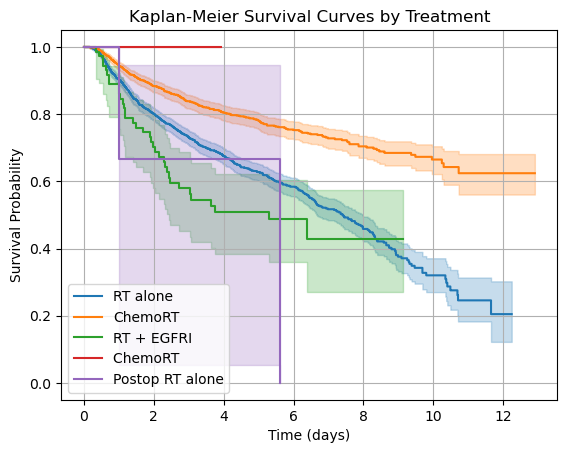

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         118.88 <0.005     89.54

In [15]:
#Kaplan-Meier Curves and Log-Rank Test

# Initialize the Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot survival for each treatment group
for group in df['Treatment'].unique():
    mask = df['Treatment'] == group
    kmf.fit(df.loc[mask, 'time'], event_observed=df.loc[mask, 'event'], label=str(group))
    kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curves by Treatment")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# Compare two groups using log-rank test
group1 = df[df['Treatment'] == df['Treatment'].unique()[0]]
group2 = df[df['Treatment'] == df['Treatment'].unique()[1]]
logrank_test(group1['time'], group2['time'], event_observed_A=group1['event'], event_observed_B=group2['event']).print_summary()


<lifelines.CoxPHFitter: fitted with 3319 total observations, 2269 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3319
number of events observed = 1050
   partial log-likelihood = -7654.86
         time fit was run = 2025-07-16 15:41:32 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
Age                         0.04      1.04      0.00            0.03            0.04                1.03                1.04
Stage_I                    -0.21      0.81      0.34           -0.87            0.45                0.42                1.57
Stage_IB                  -16.96      0.00  22465.82       -44049.15        44015.23                0.00                 inf
Stage_II                    0.07      1.07      0.33           -0.58            0.72                0.56                2.05
Stage_IIA                 -11.21      0.00    589.41        -1166.43         1144.01                0.00                 inf
Stage_IIB                   2.15      8.59      1.05            0.09            4.21                1.10               67.34
Stage_III                   0.45      1.57      0.33           -0.19            1.09                0.83                2.97
Stage_IIIA                  2.80     16.41      0.78            1.27            4.32                3.57               75.37
Stage_IIIC                  2.73     15.31      0.78            1.21            4.25                3.35               70.03
Stage_IV                    1.15      3.16      0.49            0.18            2.12                1.20                8.34
Stage_IVA                   0.78      2.17      0.32            0.15            1.40                1.16                4.08
Stage_IVB                   1.58      4.84      0.33            0.93            2.22                2.54                9.22
Stage_IVC                 -12.73      0.00   1484.37        -2922.03         2896.58                0.00                 inf
Stage_X                     1.87      6.49      0.59            0.71            3.03                2.03               20.71
Treatment_ChemoRT         -12.14      0.00    994.07        -1960.49         1936.21                0.00                 inf
Treatment_Postop RT alone   1.96      7.11      0.71            0.57            3.36                1.76               28.73
Treatment_RT + EGFRI        0.53      1.70      0.18            0.17            0.89                1.19                2.43
Treatment_RT alone          0.76      2.15      0.08            0.61            0.92                1.83                2.51

                           cmp to     z      p  -log2(p)
covariate                                               
Age                          0.00 11.33 <0.005     96.36
Stage_I                      0.00 -0.62   0.53      0.90
Stage_IB                     0.00 -0.00   1.00      0.00
Stage_II                     0.00  0.21   0.83      0.27
Stage_IIA                    0.00 -0.02   0.98      0.02
Stage_IIB                    0.00  2.05   0.04      4.62
Stage_III                    0.00  1.39   0.16      2.61
Stage_IIIA                   0.00  3.60 <0.005     11.61
Stage_IIIC                   0.00  3.52 <0.005     11.16
Stage_IV                     0.00  2.33   0.02      5.65
Stage_IVA                    0.00  2.42   0.02      5.99
Stage_IVB                    0.00  4.80 <0.005     19.29
Stage_IVC                    0.00 -0.01   0.99      0.01
Stage_X                      0.00  3.16 <0.005      9.30
Treatment_ChemoRT            0.00 -0.01   0.99      0.01
Treatment_Postop RT alone    0.00  2.75   0.01      7.41
Treatment_RT + EGFRI         0.00  2.90 <0.005      8.06
Treatment_RT alone           0.00  9.50 <0.005     68.


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 3319 total observations, 2269 right-censored observations>
         test_name = proportional_hazard_test

---
                                test_statistic      p  -log2(p)
Age                       km             13.18 <0.005     11.79
                          rank           12.10 <0.005     10.95
Stage_I                   km              0.99   0.32      1.64
                          rank            0.30   0.58      0.78
Stage_IB                  km              0.00   1.00      0.00
                          rank            0.00   1.00      0.00
Stage_II                  km              0.17   0.68      0.55
                          rank            0.01   0.91      0.14
Stage_IIA                 km              0.00   1.00      0.00
                          rank            0.00   1.00      0.00
Stage_IIB                 km              0.01   0.94      0.10
                          rank            0.00   0.97      0.05
Stage_III                 km              0.71   0.40      1.32
                          rank            1.20   0.27      1.87
Stage_IIIA                km              0.00   0.97      0.04
                          rank            0.00   0.97      0.04
Stage_IIIC                km              0.00   0.95      0.07
                          rank            0.01   0.92      0.12
Stage_IV                  km              0.43   0.51      0.97
                          rank            0.63   0.43      1.22
Stage_IVA                 km              1.15   0.28      1.82
                          rank            1.95   0.16      2.62
Stage_IVB                 km              3.48   0.06      4.01
                          rank            5.58   0.02      5.78
Stage_IVC                 km              0.00   1.00      0.00
                          rank            0.00   1.00      0.00
Stage_X                   km              0.82   0.37      1.45
                          rank            1.04   0.31      1.70
Treatment_ChemoRT         km              0.00   1.00      0.00
                          rank            0.00   1.00      0.00
Treatment_Postop RT alone km              0.49   0.48      1.05
                          rank            0.50   0.48      1.06
Treatment_RT + EGFRI      km              0.49   0.49      1.04
                          rank            0.66   0.42      1.27
Treatment_RT alone        km              0.03   0.87      0.20
                          rank            0.67   0.41      1.27



1. Variable 'Age' failed the non-proportional test: p-value is 0.0003.

   Advice 1: the functional form of the variable 'Age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Age' using pd.cut, and then specify it in `strata=['Age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment..

[[<Axes: xlabel='rank-transformed time\n(p=0.0005)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0003)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5812)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3202)'>],
 [<Axes: xlabel='rank-transformed time\n(p=1.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=1.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9089)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6819)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9988)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9989)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9654)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9355)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2736)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3992)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9698)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9750)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9193)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9503)'>],
 [<Axes: xlabel='rank-transformed tim

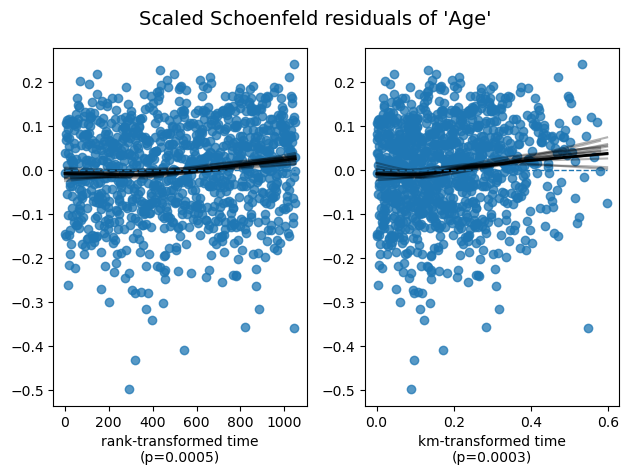

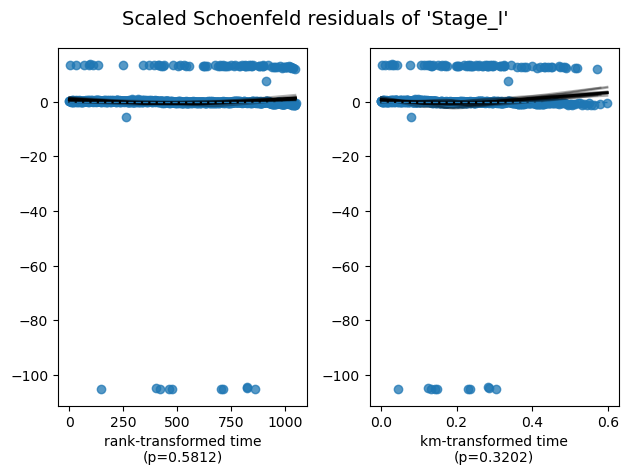

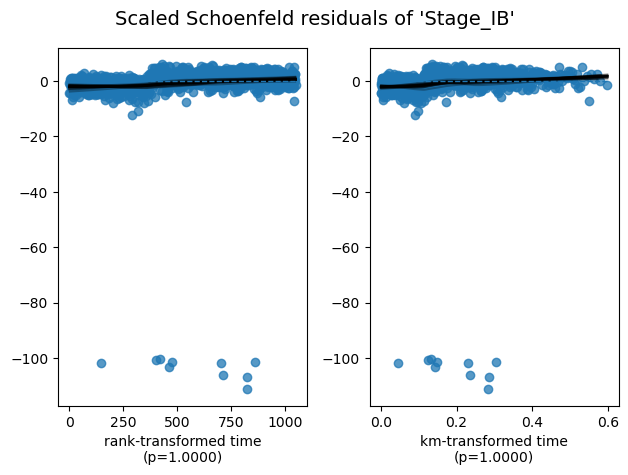

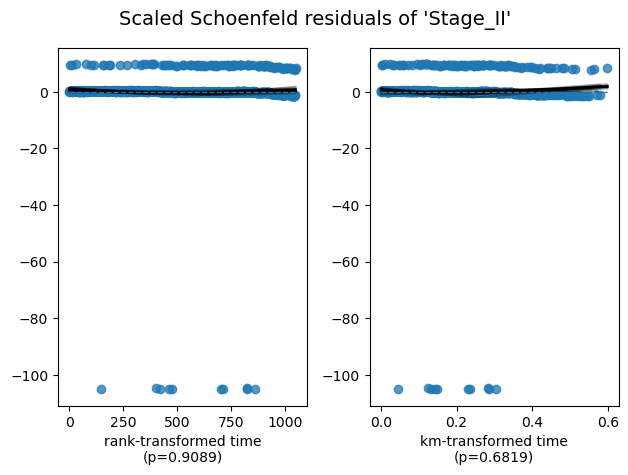

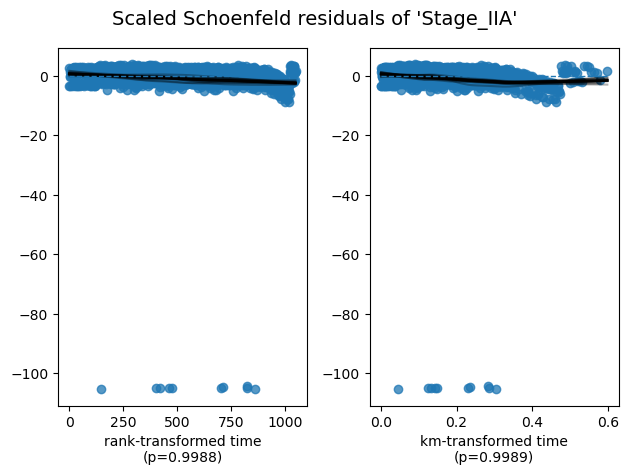

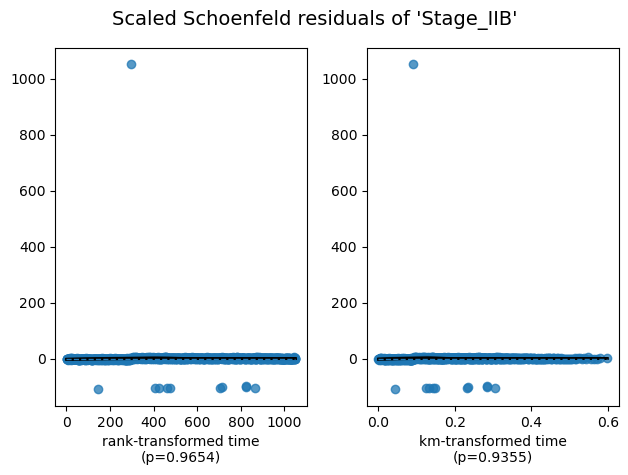

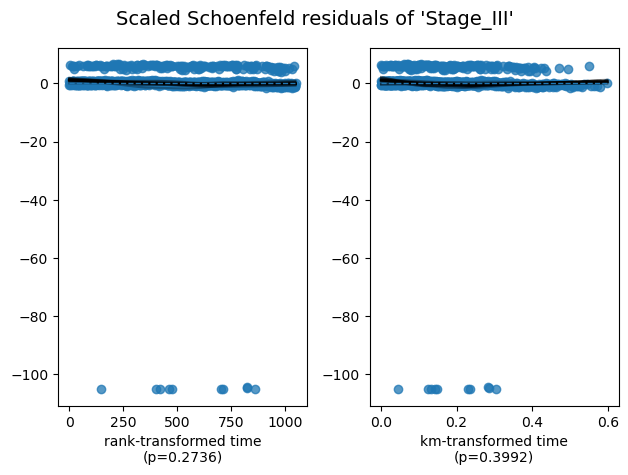

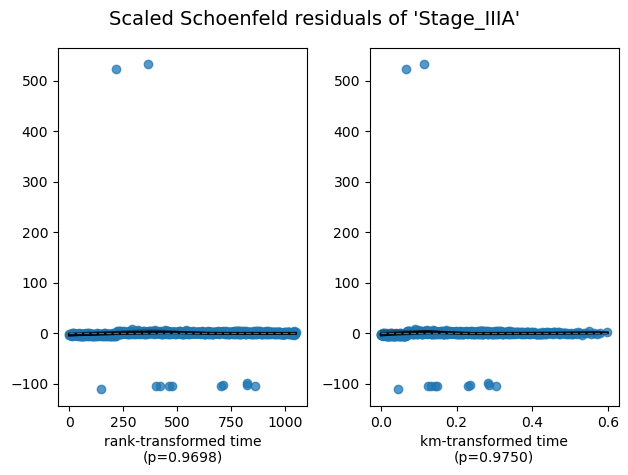

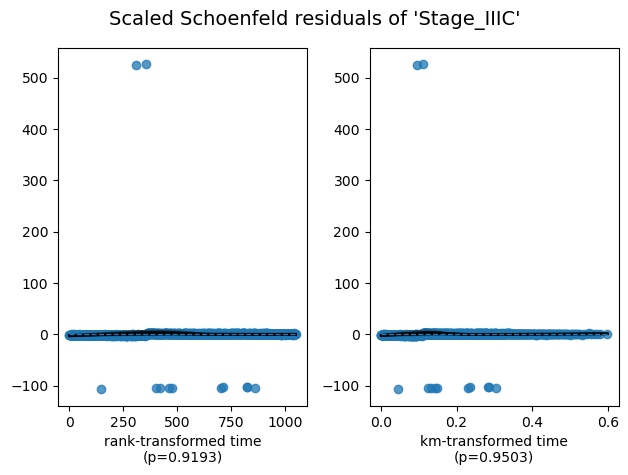

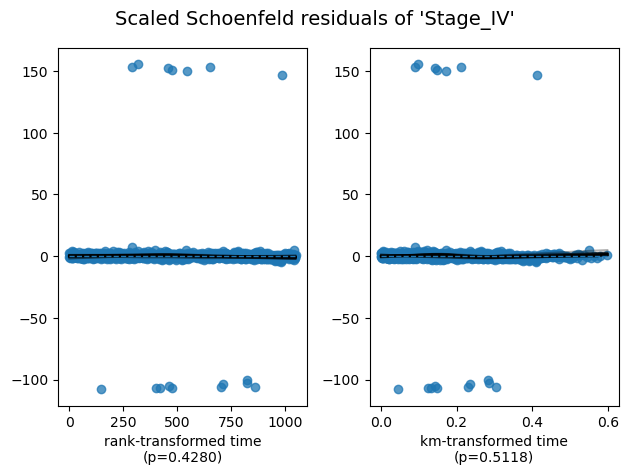

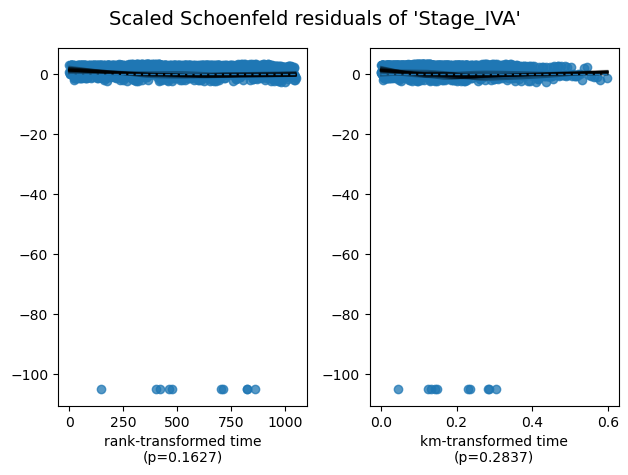

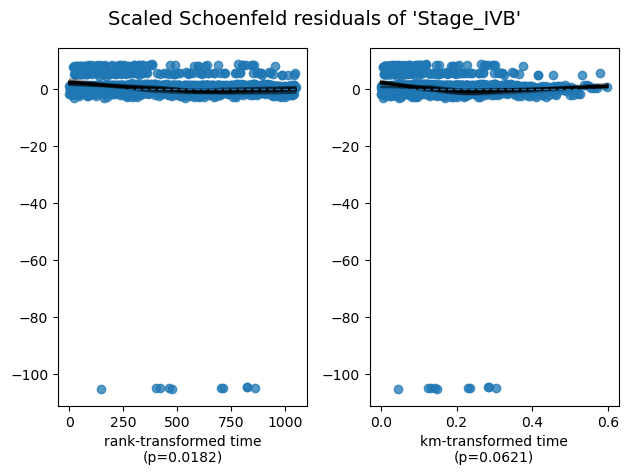

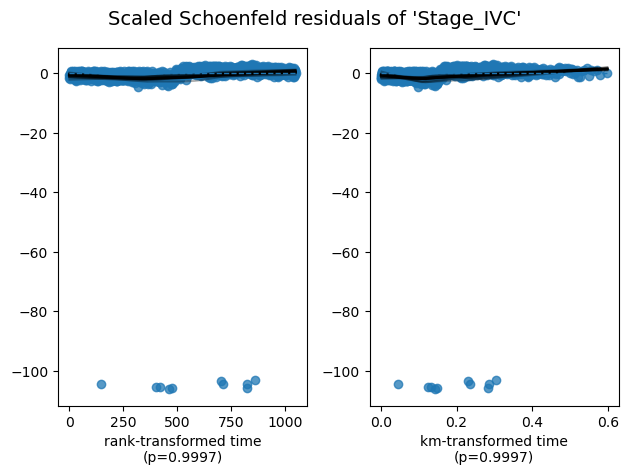

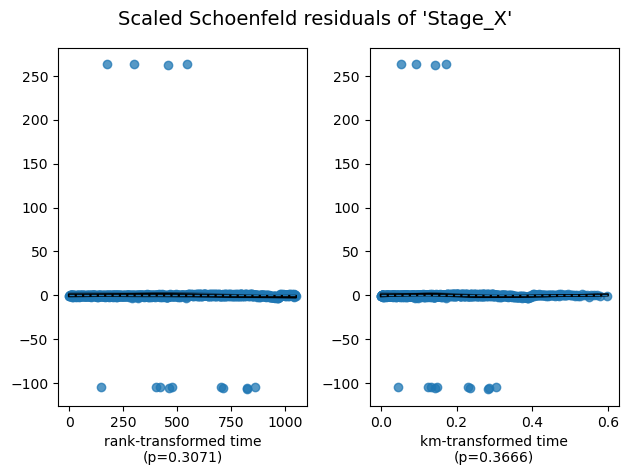

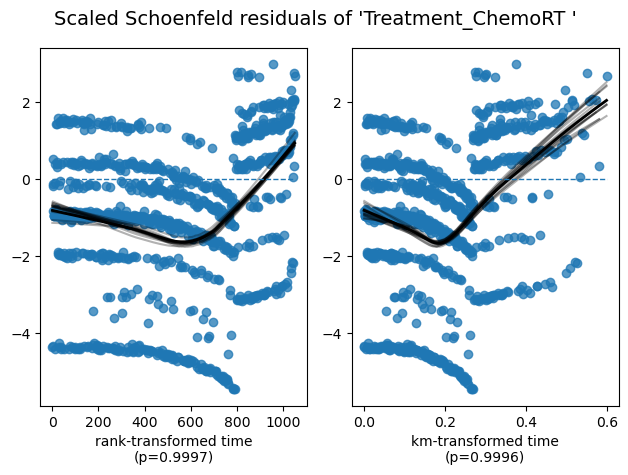

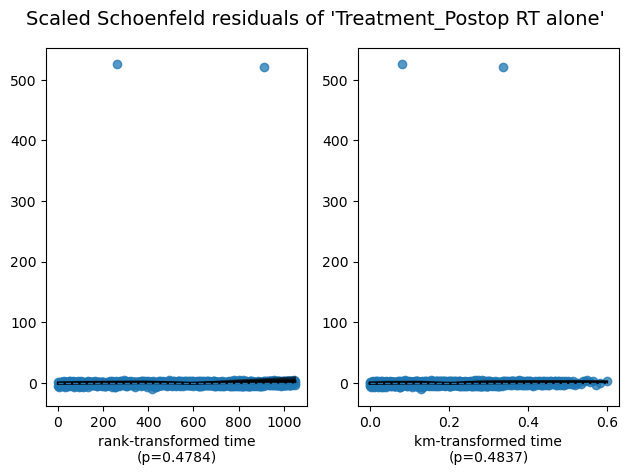

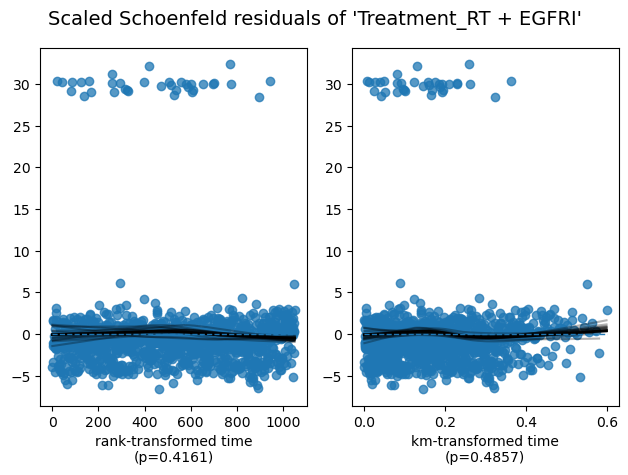

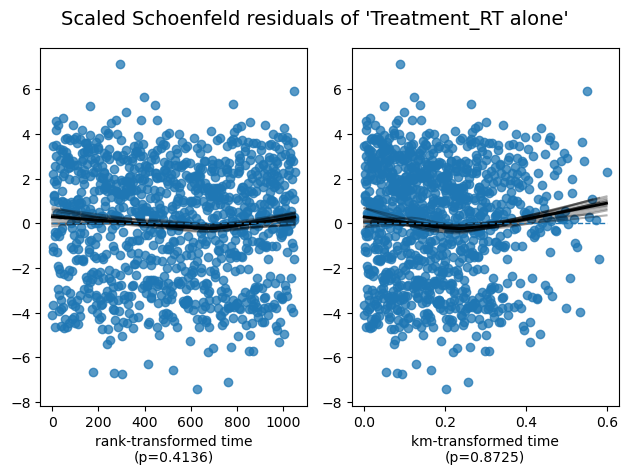

In [18]:
# Cox Proportional Hazards Regression
from lifelines import CoxPHFitter


# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Stage', 'Treatment'], drop_first=True)

# Fit Cox model
cph = CoxPHFitter()
cph.fit(df_encoded[['time', 'event', 'Age'] + [col for col in df_encoded.columns if 'Stage_' in col or 'Treatment_' in col]],
        duration_col='time', event_col='event')
cph.print_summary()

# Check proportional hazards assumption
cph.check_assumptions(df_encoded[['time', 'event', 'Age'] + [col for col in df_encoded.columns if 'Stage_' in col or 'Treatment_' in col]],
                      p_value_threshold=0.05, show_plots=True)





In [48]:
df = pd.read_csv("RADCURE_Clinical_v04_20241219.csv")
print("Raw row count:", df.shape[0])
df.head()

df = df.rename(columns={
    'Length FU': 'time',
    'Status': 'event',
    'Tx Modality': 'Treatment'
})

    # Check where missing data is most common
missing_summary = df.isnull().sum().sort_values(ascending=False)
print(missing_summary.head(10))

# Count rows with 'Unknown' in any column
unknown_count = df.apply(lambda col: col.astype(str).str.contains("Unknown")).sum().sort_values(ascending=False)
print(unknown_count.head(10))

# Drop columns with >50% missing or Unknowns
high_missing = df.columns[(df.isnull().mean() > 0.5)]
df = df.drop(columns=high_missing)

# Drop columns where more than 50% are 'Unknown'
high_unknown = df.columns[(df.astype(str).apply(lambda x: x.str.contains("Unknown").mean())) > 0.5]
df = df.drop(columns=high_unknown)

# Replace 'Unknown' with NaN for remaining safe columns
df = df.replace("Unknown", np.nan)

# Fill numeric with median
for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with most frequent value
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

print("Cleaned row count:", df.shape[0])

# RSF model
# One-hot encode any categorical columns (e.g., Stage, Treatment)
df_encoded = pd.get_dummies(df, drop_first=True)
from sksurv.util import Surv

 
 
df['event'] = df['event'].map({'Yes': True, 'No': False})


# Create survival object (target)
y_rsf = Surv.from_dataframe("Status", "time", df_encoded)
# Feature matrix (exclude 'time' and 'event')
X_encoded = df_encoded.drop(columns=["time", "Status"])


# Fit model
from sksurv.ensemble import RandomSurvivalForest
rsf = RandomSurvivalForest(n_estimators=100,
                           min_samples_split=10,
                           min_samples_leaf=15,
                           random_state=42)
rsf.fit(X_encoded, y_rsf)



# Create survival object (target)
y_rsf = Surv.from_dataframe("Status", "time", df_encoded)

# Feature matrix (exclude 'time' and 'event')
X_rsf = df_encoded.drop(columns=["time", "Status"])
from sksurv.ensemble import RandomSurvivalForest

# Initialize and fit model
rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=15,
    random_state=42
)
rsf.fit(X_rsf, y_rsf)

print("✅ RSF model trained successfully on", len(X_rsf), "patients.")

import matplotlib.pyplot as plt
import pandas as pd

# Extract and sort feature importances
importances = pd.Series(rsf.feature_importances_, index=X_rsf.columns)
importances = importances.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10, 8))
importances.plot(kind='barh')
plt.title("Feature Importance - Random Survival Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()












Raw row count: 3346
Date Regional     3157
Regional          3157
Date Local        2966
Local             2966
Distant           2933
Date Distant      2933
Date 2nd Ca       2907
2nd Ca            2905
Cause of Death    2294
Date of Death     2288
dtype: int64
Ds Site           168
Cause of Death     60
ECOG PS            31
patient_id          0
Age                 0
Smoking PY          0
Smoking Status      0
Subsite             0
T                   0
Sex                 0
dtype: int64
Cleaned row count: 3346


KeyError: 'Status'